In [1]:
import pandas as pd
import numpy as np

## Verify features-tpase tags match FASTA headers

Check that the sequence IDs in features-tpase exist in all_vgp_tes.fa and that the tags are consistent.

In [2]:
# Load FASTA headers
def get_fasta_headers(file_path):
    """Extract all headers from FASTA file"""
    headers = {}
    with open(file_path, 'r') as f:
        for line in f:
            if line.startswith('>'):
                header = line.strip()
                # Extract the class from header (after #)
                if '#' in header:
                    te_class = header.split('#')[1]
                else:
                    te_class = None
                headers[header] = te_class
    return headers

# Load features-tpase file
def load_features_tpase(file_path):
    """Load features-tpase file: header -> tag mapping"""
    features = {}
    with open(file_path, 'r') as f:
        for line in f:
            parts = line.strip().split('\t')
            if len(parts) >= 2:
                header, tag = parts[0], parts[1]
                features[header] = tag
    return features

# Load both files
fasta_path = '../data/vgp/all_vgp_tes.fa'
features_path = '../data/vgp/features-tpase'

fasta_headers = get_fasta_headers(fasta_path)
features_tpase = load_features_tpase(features_path)

print(f"FASTA file has {len(fasta_headers)} sequences")
print(f"Features-tpase file has {len(features_tpase)} entries")

FASTA file has 135751 sequences
Features-tpase file has 135751 entries


In [3]:
# Check 1: Do all features-tpase headers exist in FASTA?
missing_in_fasta = [h for h in features_tpase.keys() if h not in fasta_headers]
print(f"Headers in features-tpase but NOT in FASTA: {len(missing_in_fasta)}")
if missing_in_fasta:
    print("Examples of missing headers:")
    for h in missing_in_fasta[:5]:
        print(f"  {h}")

# Check 2: Do the tags match the class in FASTA header?
mismatches = []
matches = 0
for header, tag in features_tpase.items():
    if header in fasta_headers:
        fasta_class = fasta_headers[header]
        if fasta_class != tag:
            mismatches.append((header, tag, fasta_class))
        else:
            matches += 1

print(f"\nTag matches: {matches}")
print(f"Tag mismatches: {len(mismatches)}")
if mismatches:
    print("\nFirst 10 mismatches (header, features-tag, fasta-class):")
    for h, tag, fasta_class in mismatches[:10]:
        print(f"  {h}")
        print(f"    features-tpase tag: {tag}")
        print(f"    FASTA class:        {fasta_class}")

Headers in features-tpase but NOT in FASTA: 0

Tag matches: 10650
Tag mismatches: 125101

First 10 mismatches (header, features-tag, fasta-class):
  >ERV1_15-aAnoBae#LTR/ERV1
    features-tpase tag: None
    FASTA class:        LTR/ERV1
  >ERV1_1-aAnoBae#LTR/ERV1
    features-tpase tag: None
    FASTA class:        LTR/ERV1
  >ERV1_2-aAnoBae#LTR/ERV1
    features-tpase tag: None
    FASTA class:        LTR/ERV1
  >ERV1_3-aAnoBae#LTR/ERV1
    features-tpase tag: None
    FASTA class:        LTR/ERV1
  >Gypsy_478-aAnoBae#LTR/Gypsy
    features-tpase tag: None
    FASTA class:        LTR/Gypsy
  >Gypsy_488-aAnoBae#LTR/Gypsy
    features-tpase tag: None
    FASTA class:        LTR/Gypsy
  >Gypsy_494-aAnoBae#LTR/Gypsy
    features-tpase tag: None
    FASTA class:        LTR/Gypsy
  >Gypsy_498-aAnoBae#LTR/Gypsy
    features-tpase tag: None
    FASTA class:        LTR/Gypsy
  >Gypsy_500-aAnoBae#LTR/Gypsy
    features-tpase tag: None
    FASTA class:        LTR/Gypsy
  >Gypsy_501-aAnoBae#LTR/G

In [4]:
# Summary statistics of tags in features-tpase
from collections import Counter

tag_counts = Counter(features_tpase.values())
print("Tag distribution in features-tpase:")
print(f"Total unique tags: {len(tag_counts)}\n")
for tag, count in tag_counts.most_common():
    pct = 100 * count / len(features_tpase)
    print(f"  {tag}: {count} ({pct:.2f}%)")

Tag distribution in features-tpase:
Total unique tags: 18

  None: 125101 (92.15%)
  DNA/hAT: 4900 (3.61%)
  DNA/TcMar-Tc1: 1875 (1.38%)
  DNA: 1530 (1.13%)
  DNA/PIF-Harbinger: 790 (0.58%)
  DNA/PiggyBac: 563 (0.41%)
  DNA/Academ-1: 415 (0.31%)
  DNA/CMC: 180 (0.13%)
  DNA/Sola-2: 93 (0.07%)
  DNA/Kolobok: 86 (0.06%)
  DNA/P: 77 (0.06%)
  DNA/Sola-1: 43 (0.03%)
  DNA/PIF-ISL2EU: 38 (0.03%)
  DNA/MULE-MuDR: 23 (0.02%)
  DNA/Crypton-V: 19 (0.01%)
  DNA/Merlin: 12 (0.01%)
  DNA/Ginger-1: 4 (0.00%)
  DNA/Dada: 2 (0.00%)


In [5]:
def load_fa(file_dir):
    with open(file_dir, 'r') as f:
        lines = f.readlines()
        
    te_dict = {}
    for l in lines:
        if l.startswith('>'):
            key = l[1:-1]
            ind = len(key.split('_')[0]) + key.split('_')[1].index('-') + 1
            id = key[:ind]
            tag = key[ind + 1: key.index('#')]
            te_class = key[key.index('#') + 1:]
        else:
            seq = l[:-1]
            te_dict[key] = {'key': key, 'id': id, 'tag': tag, 'class': te_class, 'seq': seq}
    
    return te_dict

In [6]:
vgp_te_dict = load_fa('../data/vgp/all_vgp_tes.fa')

In [7]:
with open('../data/vgp/20251215-features-tpase', 'r') as f:
    lines = f.readlines()
    
    for l in lines:
        key, feature = l[1:-1].split('\t')
        if feature == "TRUE":
            vgp_te_dict[key]['feature'] = 1
        else:
            vgp_te_dict[key]['feature'] = 0

In [8]:
vgp_te_df = pd.DataFrame.from_dict(vgp_te_dict, orient='index', columns=['id', 'tag', 'class', 'seq', 'feature'])

In [9]:
vgp_te_df.iloc[:10]

,id,tag,class,seq,feature
hAT_1-aAnoBae#DNA/hAT,hAT_1,aAnoBae,DNA/hAT,TAGAGTTGAGCGCGGTTCGTGGTTCGTGGTTCTCCAGTTCGCGGCT...,0
hAT_131-aAnoBae#DNA/hAT,hAT_131,aAnoBae,DNA/hAT,TAGAGTTGAGCGCGGTTCGTGGTTCGTGGTTCTCCAGTTCGCGGCT...,0
hAT_147-aAnoBae#DNA/hAT,hAT_147,aAnoBae,DNA/hAT,TAGAGTTGAGCGCGGTTCGTGGTTCGTGGTTCTCCAGTTCGCGGCT...,0
hAT_210-aAnoBae#DNA/hAT,hAT_210,aAnoBae,DNA/hAT,TAGAGTTGAGCGCGGTTCGTGGTTCGTGGTTCTCCAGTTCGCGGCT...,0
hAT_254-aAnoBae#DNA/hAT,hAT_254,aAnoBae,DNA/hAT,TAGAGTTGAGCGCGGTTCGTGGTTCGTGGTTCTCCAGTTCGCGGCT...,0
ERV1_15-aAnoBae#LTR/ERV1,ERV1_15,aAnoBae,LTR/ERV1,TGTTGAGGATAAAGAATTGAGTATCCAAAAATACTTAATTCAGCCA...,0
hAT_292-aAnoBae#DNA/hAT,hAT_292,aAnoBae,DNA/hAT,TAGAGATGAGCGAACCGGTCCCGGTTCGGCTCGAGGCGGTTCGCCG...,0
hAT_298-aAnoBae#DNA/hAT,hAT_298,aAnoBae,DNA/hAT,TAGAGATGAGCGAACCGGTCCCGGTTCGGCTCGAGGCGGTTCGCCG...,0
hAT_299-aAnoBae#DNA/hAT,hAT_299,aAnoBae,DNA/hAT,TAGAGTTGAGCGCGGTTCGTGGTTCGTGGTTCTCCAGTTCGCGGCT...,0
PIF-Harbinger_1-aAnoBae#DNA/PIF-Harbinger,PIF-Harbinger_1,aAnoBae,DNA/PIF-Harbinger,AGGGGTGCTTCACACATAGCGAGATCGCTAGCGAGATCGCTGCTGA...,0


In [10]:
pd.to_pickle(vgp_te_df, '../data/vgp/vgp_te_features.pkl')

In [11]:
vgp_features = vgp_te_df[['seq', 'feature']].reset_index(drop=True)
vgp_features

,seq,feature
0,TAGAGTTGAGCGCGGTTCGTGGTTCGTGGTTCTCCAGTTCGCGGCT...,0
1,TAGAGTTGAGCGCGGTTCGTGGTTCGTGGTTCTCCAGTTCGCGGCT...,0
2,TAGAGTTGAGCGCGGTTCGTGGTTCGTGGTTCTCCAGTTCGCGGCT...,0
3,TAGAGTTGAGCGCGGTTCGTGGTTCGTGGTTCTCCAGTTCGCGGCT...,0
4,TAGAGTTGAGCGCGGTTCGTGGTTCGTGGTTCTCCAGTTCGCGGCT...,0
...,...,...
135746,GTTTTTGATCATAGATTTCATAGACTTTTTCATAGATTTTACAGTG...,0
135747,ATATTCAAAGACTTTTTTTTTTTAAATTTAGATTACCCAATTATTT...,0
135748,CTGGAATATCCATGATGTGAAGATGCCGGCGTTGGACTGGGGTGAG...,0
135749,CCCCACCTCCCAGGGGCTGGTTTAGCTCACNAGGGGCTGGTTTAGC...,0


In [12]:
sum(vgp_features['feature']) / len(vgp_features)

0.0

In [13]:
len_list = np.array([len(vgp_features['seq'][i]) for i in range(len(vgp_features))])
len_list.min(), len_list.max(), len_list.mean(), np.median(len_list)

(173, 19907, 3791.0058710433073, 3263.0)

In [14]:
ENCODE = np.full(256, 4, dtype=np.int64)
for ch, idx in zip(b"ACGTacgt", [0, 1, 2, 3, 0, 1, 2, 3]):
    ENCODE[ch] = idx
REV_COMP = np.array([3, 2, 1, 0, 4]) 

for i in range(10):
    seq = np.array(vgp_features['seq'])[i]
    seq_encoded = ENCODE[np.frombuffer(seq.encode(), dtype=np.uint8)]
    rev_comp = REV_COMP[seq_encoded][::-1]
    rc_seq = ''.join(np.array(['A', 'C', 'G', 'T', 'N'])[rev_comp])
    
    feature = vgp_features['feature'][i]
    print(feature)
    print(seq)
    print(rc_seq)

0
...
0
...
0
...
0
...
0
...
0
...
0
...
0
...
0
...
0
...


In [15]:
seq

'AGGGGTGCTTCACACATAGCGAGATCGCTAGCGAGATCGCTGCTGAGTCACGGTTTTGGTGACGCAATAGTGACCTCATTAGCGATCTCGCTGTGTGTGACACTGAGCAGCGATCTGGCCCCTGCTGTGAGATCGCTGCTCGTTACACACAGTGCTGGTTCGTTTTCTTCAAAGGCGATGTCCTGCTGTGCAGGACGCAATTCTGTGTGTGACTCCTAGACAGCGACCTTGTTCACGACTNACGTAGGCGTGCATCTTCGTTGGTTTCCACGCCCTCTCTGTTCTGATTGGTGATCGCTACTGCGTTCTCATTGGACGTCTCATTGGGCGTCTTCCATTGTTTGGTAGGGCTAGTTCACTTGTCCCTGACCGCGTGTAGCAAGCAGATCGCAATACAGTCCATTCTGCATCGCTTCATCCGTTCATCAGATATTCTGGGCGTTGTACTCTGCAAGGTAGGAATTTTTTTGAGGTCGCAAATACATTTCCATAATATTATTACATTTCTATAAGTATCTATCATTGTGCTATAGAACATTGTGTGTTCATGCTTCTACACTTGCAAGCAAATGGTGAGAGGGCTTGGCTACTATCTGTACACATGCTTTTCTATGGGCAGACATTTTAACCCCTTCAAGACTGACCTTTTTTTTGCTTTACGTTTTTATTTCGCCATTCTTTTTCTGAGAGACGTAATTTTTTTATTTTACAGTCAATATGGTCATGTGAGGGCTCATTTTTTTGCGGAAATAACTGTGCTTTTAAATGAAACCATAAGTTTTCCCATATAGTGTACTGTAAACCGTCCAAAAATTCCAAATGAAGAAAAATTGTAAAATAAGTGCGATAGCGTCTCAATCACATGTTTTTACCGCTAACCATTTTTGCGCATATGATATGTTTGGCTCGCCTATTATTTCATTTAGCACAAAAGTTGTGATGACATAAAAATGTCATTTTGGCGTTTGAAATGTTTTTGCCGCTATGCCGTATCGTGAT

Highly accurate ab initio gene annotation with ANNEVO

BERT AlphaGenome

## tpase

In [16]:
with open('../data/vgp/20251215-features-tpase', 'r') as f:
    lines = f.readlines()
    label_dict = {}
    for l in lines:
        header, label = l.strip().split('\t')
        label_dict[header] = label_dict.get(header, label)

label_mismatches, mismatches = {}, 0
for key in list(label_dict.keys()):
    trailing = key.split('#')[1]
    if trailing != label_dict[key] and ('DNA' in key or 'DNA' in trailing):
        label_mismatches[key] = (label_dict[key], trailing)
        mismatches += 1

print(f"Total mismatches: {mismatches}")
label_mismatches

Total mismatches: 18856


{'>Unknown_36-aAnoBae#DNA/hAT': ('None', 'DNA/hAT'),
 '>Unknown_42-aAnoBae#DNA': ('None', 'DNA'),
 '>Unknown_47-aAnoBae#DNA/hAT': ('None', 'DNA/hAT'),
 '>Unknown_48-aAnoBae#DNA/hAT': ('None', 'DNA/hAT'),
 '>Unknown_51-aAnoBae#DNA/hAT': ('None', 'DNA/hAT'),
 '>Unknown_52-aAnoBae#DNA/hAT': ('None', 'DNA/hAT'),
 '>Unknown_53-aAnoBae#DNA/hAT': ('None', 'DNA/hAT'),
 '>Unknown_57-aAnoBae#DNA/hAT': ('None', 'DNA/hAT'),
 '>hAT_111-aAnoBae#DNA/hAT': ('None', 'DNA/hAT'),
 '>Unknown_59-aAnoBae#DNA/hAT': ('None', 'DNA/hAT'),
 '>Unknown_60-aAnoBae#DNA/hAT': ('None', 'DNA/hAT'),
 '>Unknown_61-aAnoBae#DNA/hAT': ('None', 'DNA/hAT'),
 '>Unknown_62-aAnoBae#DNA/hAT': ('None', 'DNA/hAT'),
 '>Unknown_66-aAnoBae#DNA/hAT': ('None', 'DNA/hAT'),
 '>Unknown_70-aAnoBae#DNA/hAT': ('None', 'DNA/hAT'),
 '>Unknown_72-aAnoBae#DNA/hAT': ('None', 'DNA/hAT'),
 '>Unknown_77-aAnoBae#DNA': ('None', 'DNA'),
 '>Unknown_78-aAnoBae#DNA': ('None', 'DNA'),
 '>hAT_112-aAnoBae#DNA': ('None', 'DNA'),
 '>Unknown_79-aAnoBae#DNA': ('N

In [17]:
def load_labels_binary(path):
    label_dict = {}
    with open(path, 'r') as f:
        for line in f:
            if not line:
                continue
            parts = line.strip().split('\t')
            header = parts[0][1:]
            if parts[1] == "None":
                label = 0.0
            else:
                label = 1.0
            label_dict[header] = label
    return label_dict

label_dict = load_labels_binary("../data/vgp/20251215-features-tpase")

In [18]:
label_dict

{'hAT_1-aAnoBae#DNA/hAT': 1.0,
 'hAT_131-aAnoBae#DNA/hAT': 1.0,
 'hAT_147-aAnoBae#DNA/hAT': 1.0,
 'hAT_210-aAnoBae#DNA/hAT': 1.0,
 'hAT_254-aAnoBae#DNA/hAT': 1.0,
 'ERV1_15-aAnoBae#LTR/ERV1': 0.0,
 'hAT_292-aAnoBae#DNA/hAT': 1.0,
 'hAT_298-aAnoBae#DNA/hAT': 1.0,
 'hAT_299-aAnoBae#DNA/hAT': 1.0,
 'PIF-Harbinger_1-aAnoBae#DNA/PIF-Harbinger': 1.0,
 'hAT_23-aAnoBae#DNA/hAT': 1.0,
 'ERV1_1-aAnoBae#LTR/ERV1': 0.0,
 'hAT_39-aAnoBae#DNA/hAT': 1.0,
 'hAT_69-aAnoBae#DNA/hAT': 1.0,
 'hAT_90-aAnoBae#DNA/hAT': 1.0,
 'hAT_110-aAnoBae#DNA/hAT': 1.0,
 'hAT_116-aAnoBae#DNA/hAT': 1.0,
 'hAT_124-aAnoBae#DNA/hAT': 1.0,
 'hAT_130-aAnoBae#DNA/hAT': 1.0,
 'ERV1_2-aAnoBae#LTR/ERV1': 0.0,
 'ERV1_3-aAnoBae#LTR/ERV1': 0.0,
 'hAT_132-aAnoBae#DNA/hAT': 1.0,
 'hAT_133-aAnoBae#DNA/hAT': 1.0,
 'hAT_134-aAnoBae#DNA/hAT': 1.0,
 'hAT_136-aAnoBae#DNA/hAT': 1.0,
 'hAT_137-aAnoBae#DNA/hAT': 1.0,
 'hAT_138-aAnoBae#DNA/hAT': 1.0,
 'Gypsy_478-aAnoBae#LTR/Gypsy': 0.0,
 'Gypsy_488-aAnoBae#LTR/Gypsy': 0.0,
 'hAT_148-aAnoBae#DNA/

In [20]:
def load_labels(path):
    label_dict = {}
    labels, index = {}, 0
    with open(path, 'r') as f:
        for line in f:
            if not line:
                continue
            parts = line.strip().split('\t')
            header = parts[0][1:]
            
            if parts[1] not in labels.keys():
                labels[parts[1]] = index
                index += 1
            label_dict[header] = labels[parts[1]]
            
    return label_dict

label_dict = load_labels("../data/vgp/features-tpase")

In [21]:
label_dict

{'hAT_1-aAnoBae#DNA/hAT': 0,
 'hAT_131-aAnoBae#DNA/hAT': 0,
 'hAT_147-aAnoBae#DNA/hAT': 0,
 'hAT_210-aAnoBae#DNA/hAT': 0,
 'hAT_254-aAnoBae#DNA/hAT': 0,
 'ERV1_15-aAnoBae#LTR/ERV1': 1,
 'hAT_292-aAnoBae#DNA/hAT': 0,
 'hAT_298-aAnoBae#DNA/hAT': 0,
 'hAT_299-aAnoBae#DNA/hAT': 0,
 'PIF-Harbinger_1-aAnoBae#DNA/PIF-Harbinger': 2,
 'hAT_23-aAnoBae#DNA/hAT': 0,
 'ERV1_1-aAnoBae#LTR/ERV1': 1,
 'hAT_39-aAnoBae#DNA/hAT': 0,
 'hAT_69-aAnoBae#DNA/hAT': 0,
 'hAT_90-aAnoBae#DNA/hAT': 0,
 'hAT_110-aAnoBae#DNA/hAT': 0,
 'hAT_116-aAnoBae#DNA/hAT': 0,
 'hAT_124-aAnoBae#DNA/hAT': 0,
 'hAT_130-aAnoBae#DNA/hAT': 0,
 'ERV1_2-aAnoBae#LTR/ERV1': 1,
 'ERV1_3-aAnoBae#LTR/ERV1': 1,
 'hAT_132-aAnoBae#DNA/hAT': 0,
 'hAT_133-aAnoBae#DNA/hAT': 0,
 'hAT_134-aAnoBae#DNA/hAT': 0,
 'hAT_136-aAnoBae#DNA/hAT': 0,
 'hAT_137-aAnoBae#DNA/hAT': 0,
 'hAT_138-aAnoBae#DNA/hAT': 0,
 'Gypsy_478-aAnoBae#LTR/Gypsy': 1,
 'Gypsy_488-aAnoBae#LTR/Gypsy': 1,
 'hAT_148-aAnoBae#DNA/hAT': 0,
 'Gypsy_494-aAnoBae#LTR/Gypsy': 1,
 'Gypsy_498-aA

In [ ]:
count = [0 for _ in range(18)]
for key in label_dict.keys():
    count[label_dict[key]] += 1
count

[4900,
 125101,
 790,
 563,
 180,
 1875,
 1530,
 23,
 93,
 4,
 12,
 415,
 43,
 38,
 19,
 86,
 77,
 2]

# Analysis: New Multi-Superfamily Dataset (20260120_features_sf)

This dataset includes superfamily classification for **all TE types** (DNA, LTR, LINE, SINE, PLE, RC), not just DNA. 

- **"None"** contains both "true none" and "uncertain/low-confidence" elements
- For training, we can either:
  1. Replace binary head with multi-class (None vs DNA vs LTR vs LINE vs SINE vs PLE vs RC)
  2. Drop "None" samples during training (use only high-confidence labeled data)

In [ ]:
# ============ Dataset Analysis: Superfamily Distribution ============
from collections import Counter
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

LABEL_PATH = "../data/vgp/20260120_features_sf"

# Parse the new label file
def analyze_labels(label_path):
    """Analyze superfamily distribution in the new dataset."""
    superfamilies = Counter()
    top_classes = Counter()  # DNA, LTR, LINE, etc.
    
    with open(label_path, 'r') as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith("#"):
                continue
            parts = line.split()
            if len(parts) < 2:
                continue
            tag = parts[1]
            superfamilies[tag] += 1
            top_class = tag.split('/')[0]
            top_classes[top_class] += 1
    
    return superfamilies, top_classes

sf_counts, class_counts = analyze_labels(LABEL_PATH)
total = sum(sf_counts.values())

print(f"Total entries: {total:,}")
print(f"\n{'='*60}")
print("TOP-LEVEL CLASS DISTRIBUTION:")
print(f"{'='*60}")
for cls, count in sorted(class_counts.items(), key=lambda x: -x[1]):
    pct = 100 * count / total
    bar = '█' * int(pct / 2)
    print(f"  {cls:8s}: {count:6,} ({pct:5.1f}%) {bar}")

print(f"\n{'='*60}")
print(f"SUPERFAMILY DISTRIBUTION ({len(sf_counts)} unique):")
print(f"{'='*60}")
for sf, count in sorted(sf_counts.items(), key=lambda x: -x[1])[:25]:
    pct = 100 * count / total
    print(f"  {sf:25s}: {count:6,} ({pct:5.2f}%)")
if len(sf_counts) > 25:
    print(f"  ... and {len(sf_counts) - 25} more superfamilies")

# Labeled (non-None) statistics
labeled = {k: v for k, v in sf_counts.items() if k != 'None'}
labeled_total = sum(labeled.values())
print(f"\n{'='*60}")
print(f"HIGH-CONFIDENCE LABELED SAMPLES (excluding None):")
print(f"{'='*60}")
print(f"  Total labeled: {labeled_total:,} ({100*labeled_total/total:.1f}%)")
print(f"  None (uncertain): {sf_counts['None']:,} ({100*sf_counts['None']/total:.1f}%)")

Total entries: 135,751

TOP-LEVEL CLASS DISTRIBUTION:
  None    : 84,512 ( 62.3%) ███████████████████████████████
  LTR     : 25,568 ( 18.8%) █████████
  LINE    : 14,084 ( 10.4%) █████
  DNA     : 10,779 (  7.9%) ███
  SINE    :    566 (  0.4%) 
  PLE     :    151 (  0.1%) 
  RC      :     91 (  0.1%) 

SUPERFAMILY DISTRIBUTION (47 unique):
  None                     : 84,512 (62.26%)
  LTR/Gypsy                : 11,913 ( 8.78%)
  LINE/L1                  :  7,184 ( 5.29%)
  LTR/DIRS                 :  7,108 ( 5.24%)
  DNA/hAT                  :  4,900 ( 3.61%)
  LINE/CR1                 :  2,416 ( 1.78%)
  LINE/L2                  :  1,903 ( 1.40%)
  DNA/TcMar-Tc1            :  1,875 ( 1.38%)
  LTR/ERV1                 :  1,709 ( 1.26%)
  LTR/Pao                  :  1,578 ( 1.16%)
  DNA                      :  1,530 ( 1.13%)
  LTR/ERV2                 :  1,116 ( 0.82%)
  LINE/RTE                 :    988 ( 0.73%)
  LTR                      :    953 ( 0.70%)
  LINE/Rex-Babar          

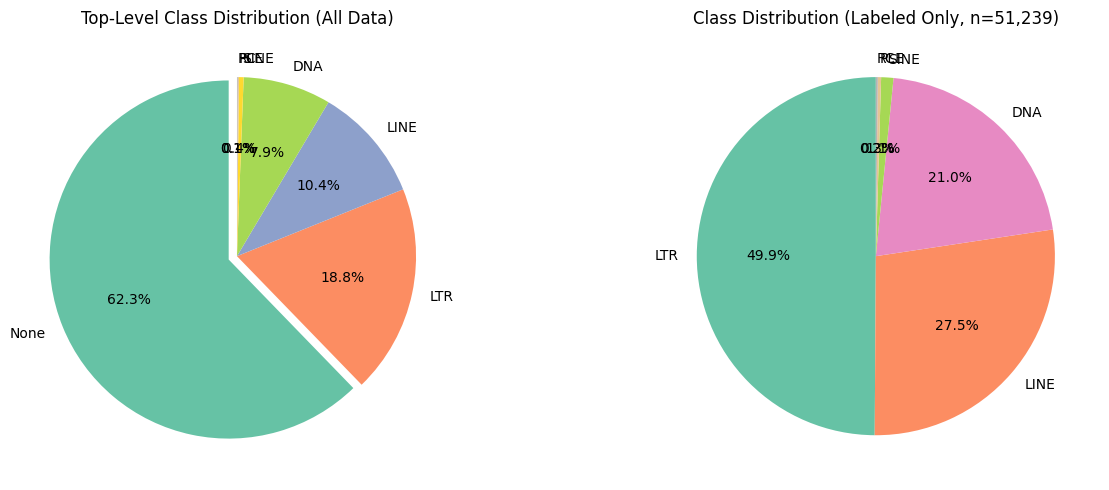

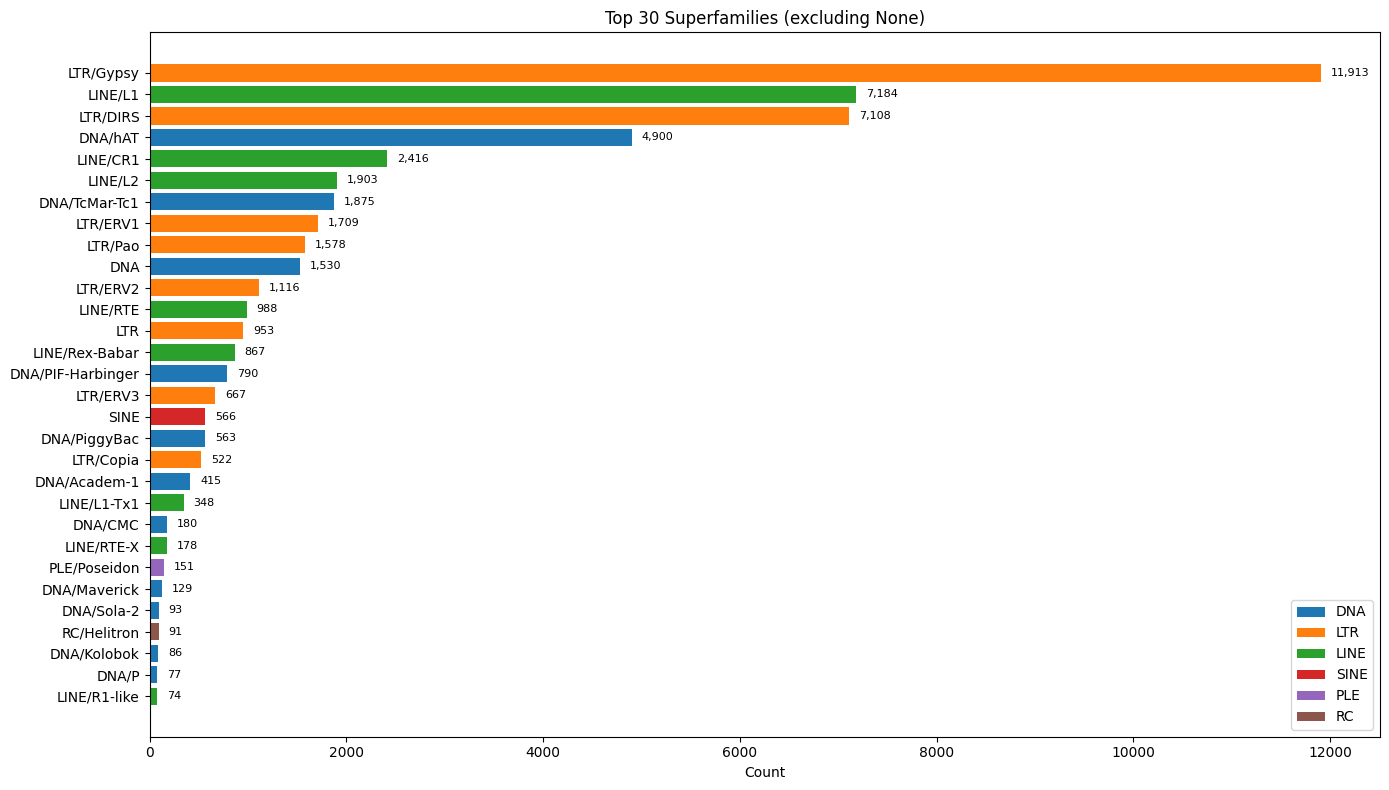

In [ ]:
# ============ Visualize Class Distribution ============
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Top-level class distribution (pie chart)
ax1 = axes[0]
classes = [cls for cls, _ in sorted(class_counts.items(), key=lambda x: -x[1])]
counts = [class_counts[cls] for cls in classes]
colors = plt.cm.Set2(np.linspace(0, 1, len(classes)))
explode = [0.05 if cls == 'None' else 0 for cls in classes]
ax1.pie(counts, labels=classes, autopct='%1.1f%%', colors=colors, explode=explode, startangle=90)
ax1.set_title('Top-Level Class Distribution (All Data)')

# Right: Labeled-only class distribution (excluding None)
ax2 = axes[1]
labeled_classes = [cls for cls in classes if cls != 'None']
labeled_counts = [class_counts[cls] for cls in labeled_classes]
colors2 = plt.cm.Set2(np.linspace(0, 1, len(labeled_classes)))
ax2.pie(labeled_counts, labels=labeled_classes, autopct='%1.1f%%', colors=colors2, startangle=90)
ax2.set_title(f'Class Distribution (Labeled Only, n={sum(labeled_counts):,})')

plt.tight_layout()
plt.savefig('superfamily_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Bar chart for superfamily counts
fig, ax = plt.subplots(figsize=(14, 8))
sf_sorted = sorted(sf_counts.items(), key=lambda x: -x[1])
sf_names = [sf for sf, _ in sf_sorted if sf != 'None'][:30]  # Top 30 excluding None
sf_values = [sf_counts[sf] for sf in sf_names]

# Color by top-level class
class_colors = {'DNA': '#1f77b4', 'LTR': '#ff7f0e', 'LINE': '#2ca02c', 
                'SINE': '#d62728', 'PLE': '#9467bd', 'RC': '#8c564b'}
bar_colors = [class_colors.get(sf.split('/')[0], '#7f7f7f') for sf in sf_names]

bars = ax.barh(range(len(sf_names)), sf_values, color=bar_colors)
ax.set_yticks(range(len(sf_names)))
ax.set_yticklabels(sf_names)
ax.invert_yaxis()
ax.set_xlabel('Count')
ax.set_title('Top 30 Superfamilies (excluding None)')

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=cls) for cls, c in class_colors.items()]
ax.legend(handles=legend_elements, loc='lower right')

# Add count labels
for i, (v, sf) in enumerate(zip(sf_values, sf_names)):
    ax.text(v + 100, i, f'{v:,}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('superfamily_distribution_bar.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ============ Training Options Analysis ============
print("="*60)
print("TRAINING OPTIONS FOR MULTI-SUPERFAMILY MODEL:")
print("="*60)

MIN_CLASS_COUNT = 100  # Current threshold from v6

# Group by top-level class
class_sf_map = {}
for sf, count in sf_counts.items():
    if sf == 'None':
        continue
    top_class = sf.split('/')[0]
    if top_class not in class_sf_map:
        class_sf_map[top_class] = []
    class_sf_map[top_class].append((sf, count))

print("\n🔹 OPTION 1: Multi-class head (DNA vs LTR vs LINE vs ...)")
print("-" * 50)
for cls in ['DNA', 'LTR', 'LINE', 'SINE', 'PLE', 'RC']:
    if cls in class_sf_map:
        total_cls = sum(c for _, c in class_sf_map[cls])
        n_sf = len(class_sf_map[cls])
        viable = sum(1 for _, c in class_sf_map[cls] if c >= MIN_CLASS_COUNT)
        print(f"  {cls:6s}: {total_cls:6,} samples | {n_sf:2d} superfamilies ({viable} with >={MIN_CLASS_COUNT} samples)")

print(f"\n  Total labeled (high-confidence): {labeled_total:,}")
print(f"  Could add 'None' as a class? Consider if {sf_counts['None']:,} are 'true none' or 'uncertain'")

print("\n🔹 OPTION 2: Drop None during training")
print("-" * 50)
print(f"  Train only on high-confidence samples: {labeled_total:,}")
print(f"  None samples ({sf_counts['None']:,}) can be used for:")
print("    - Inference/prediction only")
print("    - Semi-supervised learning")
print("    - Out-of-distribution detection")

print("\n🔹 OPTION 3: Hierarchical multi-head (current + extended)")
print("-" * 50)
print("  Head 1: Binary (labeled vs None) - like current setup")
print("  Head 2: Top-level class (DNA/LTR/LINE/SINE/PLE/RC)")  
print("  Head 3: Superfamily within class")

# Show viable superfamilies per class
print(f"\n{'='*60}")
print(f"VIABLE SUPERFAMILIES (>={MIN_CLASS_COUNT} samples):")
print(f"{'='*60}")
for cls in ['DNA', 'LTR', 'LINE', 'SINE', 'PLE', 'RC']:
    if cls in class_sf_map:
        viable = [(sf, c) for sf, c in class_sf_map[cls] if c >= MIN_CLASS_COUNT]
        if viable:
            print(f"\n{cls}:")
            for sf, c in sorted(viable, key=lambda x: -x[1]):
                print(f"    {sf}: {c:,}")

TRAINING OPTIONS FOR MULTI-SUPERFAMILY MODEL:

🔹 OPTION 1: Multi-class head (DNA vs LTR vs LINE vs ...)
--------------------------------------------------
  DNA   : 10,779 samples | 18 superfamilies (8 with >=100 samples)
  LTR   : 25,568 samples | 10 superfamilies (8 with >=100 samples)
  LINE  : 14,084 samples | 15 superfamilies (7 with >=100 samples)
  SINE  :    566 samples |  1 superfamilies (1 with >=100 samples)
  PLE   :    151 samples |  1 superfamilies (1 with >=100 samples)
  RC    :     91 samples |  1 superfamilies (0 with >=100 samples)

  Total labeled (high-confidence): 51,239
  Could add 'None' as a class? Consider if 84,512 are 'true none' or 'uncertain'

🔹 OPTION 2: Drop None during training
--------------------------------------------------
  Train only on high-confidence samples: 51,239
  None samples (84,512) can be used for:
    - Inference/prediction only
    - Semi-supervised learning
    - Out-of-distribution detection

🔹 OPTION 3: Hierarchical multi-head (cur

## Final Dataset: DNA + LTR + LINE only (drop None, SINE, PLE, RC)

In [ ]:
# ============ Final Dataset Analysis: DNA + LTR + LINE ============
# Current v6 strategy:
#   - MIN_CLASS_COUNT = 100 (drop superfamilies with <100 samples)
#   - subsample_none = 10000 (subsample None to balance with DNA+)
#   - NO subsampling of large families (all samples kept)

KEEP_CLASSES = ['DNA', 'LTR', 'LINE']
MIN_CLASS_COUNT = 100  # Same as v6

# Filter to keep only DNA, LTR, LINE with >=100 samples
final_sf = {}
for sf, count in sf_counts.items():
    top_class = sf.split('/')[0]
    if top_class in KEEP_CLASSES and count >= MIN_CLASS_COUNT:
        final_sf[sf] = count

print(f"{'='*70}")
print(f"FINAL DATASET (DNA + LTR + LINE, >={MIN_CLASS_COUNT} samples)")
print(f"{'='*70}")

# Group by class
final_by_class = {}
for sf, count in final_sf.items():
    top_class = sf.split('/')[0]
    if top_class not in final_by_class:
        final_by_class[top_class] = []
    final_by_class[top_class].append((sf, count))

total_samples = sum(final_sf.values())
print(f"\nTotal samples: {total_samples:,}")
print(f"Total superfamilies: {len(final_sf)}")

for cls in KEEP_CLASSES:
    if cls in final_by_class:
        sfs = final_by_class[cls]
        cls_total = sum(c for _, c in sfs)
        print(f"\n{cls} ({cls_total:,} samples, {len(sfs)} superfamilies):")
        for sf, count in sorted(sfs, key=lambda x: -x[1]):
            pct = 100 * count / total_samples
            print(f"    {sf:25s}: {count:6,} ({pct:5.2f}%)")

# Class imbalance analysis
print(f"\n{'='*70}")
print("CLASS IMBALANCE ANALYSIS:")
print(f"{'='*70}")
class_totals = {cls: sum(c for _, c in sfs) for cls, sfs in final_by_class.items()}
max_class = max(class_totals.values())
min_class = min(class_totals.values())
print(f"  Largest class:  {max(class_totals, key=class_totals.get):6s} = {max_class:,}")
print(f"  Smallest class: {min(class_totals, key=class_totals.get):6s} = {min_class:,}")
print(f"  Imbalance ratio: {max_class / min_class:.1f}x")

# Superfamily imbalance
sf_counts_list = sorted(final_sf.values(), reverse=True)
print(f"\n  Largest superfamily:  {max(final_sf, key=final_sf.get):20s} = {sf_counts_list[0]:,}")
print(f"  Smallest superfamily: {min(final_sf, key=final_sf.get):20s} = {sf_counts_list[-1]:,}")
print(f"  SF Imbalance ratio: {sf_counts_list[0] / sf_counts_list[-1]:.1f}x")

FINAL DATASET (DNA + LTR + LINE, >=100 samples)

Total samples: 49,832
Total superfamilies: 23

DNA (10,382 samples, 8 superfamilies):
    DNA/hAT                  :  4,900 ( 9.83%)
    DNA/TcMar-Tc1            :  1,875 ( 3.76%)
    DNA                      :  1,530 ( 3.07%)
    DNA/PIF-Harbinger        :    790 ( 1.59%)
    DNA/PiggyBac             :    563 ( 1.13%)
    DNA/Academ-1             :    415 ( 0.83%)
    DNA/CMC                  :    180 ( 0.36%)
    DNA/Maverick             :    129 ( 0.26%)

LTR (25,566 samples, 8 superfamilies):
    LTR/Gypsy                : 11,913 (23.91%)
    LTR/DIRS                 :  7,108 (14.26%)
    LTR/ERV1                 :  1,709 ( 3.43%)
    LTR/Pao                  :  1,578 ( 3.17%)
    LTR/ERV2                 :  1,116 ( 2.24%)
    LTR                      :    953 ( 1.91%)
    LTR/ERV3                 :    667 ( 1.34%)
    LTR/Copia                :    522 ( 1.05%)

LINE (13,884 samples, 7 superfamilies):
    LINE/L1                  :  

In [ ]:
# ============ Subsampling Strategy Options ============
print(f"{'='*70}")
print("SUBSAMPLING STRATEGY OPTIONS:")
print(f"{'='*70}")

# Current v6: NO subsampling of large families
print("\n📌 CURRENT v6 STRATEGY:")
print("   - Filter: Drop superfamilies with <100 samples")
print("   - Subsample: Only 'None' class is subsampled (now dropped entirely)")
print("   - Large families: ALL samples kept (no cap)")
print("   - Class weighting: inv_sqrt weighting in loss function")

# Quick stats
print(f"\n📊 With current strategy (no subsampling):")
print(f"   Total: {total_samples:,} samples across {len(final_sf)} superfamilies")

# Option 1: Cap at max_per_class
MAX_PER_SF_OPTIONS = [2000, 3000, 5000, None]
print(f"\n📊 Effect of different MAX_PER_SUPERFAMILY caps:")
print(f"   {'Cap':>6s} | {'Samples':>8s} | {'LTR/Gypsy':>10s} | {'LINE/L1':>10s} | Notes")
print(f"   {'-'*6} | {'-'*8} | {'-'*10} | {'-'*10} | {'-'*20}")

for cap in MAX_PER_SF_OPTIONS:
    if cap is None:
        capped_total = total_samples
        gypsy_kept = final_sf.get('LTR/Gypsy', 0)
        l1_kept = final_sf.get('LINE/L1', 0)
        note = "Current (no cap)"
    else:
        capped_total = sum(min(c, cap) for c in final_sf.values())
        gypsy_kept = min(final_sf.get('LTR/Gypsy', 0), cap)
        l1_kept = min(final_sf.get('LINE/L1', 0), cap)
        note = f"Affects {sum(1 for c in final_sf.values() if c > cap)} SFs"
    
    cap_str = str(cap) if cap else "None"
    print(f"   {cap_str:>6s} | {capped_total:>8,} | {gypsy_kept:>10,} | {l1_kept:>10,} | {note}")

print(f"\n💡 RECOMMENDATION:")
print("   The current v6 uses class-weighted loss (inv_sqrt) to handle imbalance.")
print("   This works well and avoids losing data from large families.")
print("   If you want to cap, MAX_PER_SF=3000 or 5000 is reasonable.")
print("   But with only ~50k samples, keeping all data is probably fine.")

SUBSAMPLING STRATEGY OPTIONS:

📌 CURRENT v6 STRATEGY:
   - Filter: Drop superfamilies with <100 samples
   - Subsample: Only 'None' class is subsampled (now dropped entirely)
   - Large families: ALL samples kept (no cap)
   - Class weighting: inv_sqrt weighting in loss function

📊 With current strategy (no subsampling):
   Total: 49,832 samples across 23 superfamilies

📊 Effect of different MAX_PER_SUPERFAMILY caps:
      Cap |  Samples |  LTR/Gypsy |    LINE/L1 | Notes
   ------ | -------- | ---------- | ---------- | --------------------
     2000 |   26,311 |      2,000 |      2,000 | Affects 5 SFs
     3000 |   30,727 |      3,000 |      3,000 | Affects 4 SFs
     5000 |   38,627 |      5,000 |      5,000 | Affects 3 SFs
     None |   49,832 |     11,913 |      7,184 | Current (no cap)

💡 RECOMMENDATION:
   The current v6 uses class-weighted loss (inv_sqrt) to handle imbalance.
   This works well and avoids losing data from large families.
   If you want to cap, MAX_PER_SF=3000 or 

In [ ]:
# ============ Analysis: Including SINE, PLE, RC with cap=3000 ============
MAX_PER_SF = 3000
ALL_CLASSES = ['DNA', 'LTR', 'LINE', 'SINE', 'PLE', 'RC']

# Build full dataset including small classes
full_sf = {}
for sf, count in sf_counts.items():
    top_class = sf.split('/')[0]
    if top_class in ALL_CLASSES and count >= MIN_CLASS_COUNT:
        full_sf[sf] = count

# Special case: RC/Helitron has only 91 samples, below MIN_CLASS_COUNT=100
# Include it anyway for analysis
if 'RC/Helitron' not in full_sf and sf_counts.get('RC/Helitron', 0) > 0:
    full_sf['RC/Helitron'] = sf_counts['RC/Helitron']

print(f"{'='*70}")
print(f"INCLUDING SINE, PLE, RC (with cap={MAX_PER_SF})")
print(f"{'='*70}")

# Group by class and apply cap
full_by_class = {}
for sf, count in full_sf.items():
    top_class = sf.split('/')[0]
    capped = min(count, MAX_PER_SF) if count > MAX_PER_SF else count
    if top_class not in full_by_class:
        full_by_class[top_class] = []
    full_by_class[top_class].append((sf, count, capped))

# Calculate class totals (with and without cap)
print("\n📊 TOP-LEVEL CLASS DISTRIBUTION (First Head):")
print(f"   {'Class':8s} | {'Original':>10s} | {'Capped':>10s} | {'% of Total':>10s} | {'SFs':>4s}")
print(f"   {'-'*8} | {'-'*10} | {'-'*10} | {'-'*10} | {'-'*4}")

total_capped = sum(min(c, MAX_PER_SF) for c in full_sf.values())
class_stats = {}
for cls in ALL_CLASSES:
    if cls in full_by_class:
        sfs = full_by_class[cls]
        orig = sum(c for _, c, _ in sfs)
        capped = sum(cap for _, _, cap in sfs)
        pct = 100 * capped / total_capped
        class_stats[cls] = {'orig': orig, 'capped': capped, 'pct': pct, 'n_sf': len(sfs)}
        print(f"   {cls:8s} | {orig:>10,} | {capped:>10,} | {pct:>9.1f}% | {len(sfs):>4}")

print(f"   {'-'*8} | {'-'*10} | {'-'*10} | {'-'*10} | {'-'*4}")
print(f"   {'TOTAL':8s} | {sum(full_sf.values()):>10,} | {total_capped:>10,} | {'100.0%':>10s} |")

# Check imbalance for first head
print(f"\n⚠️  FIRST HEAD CLASS IMBALANCE ANALYSIS:")
capped_totals = {cls: s['capped'] for cls, s in class_stats.items()}
max_cls = max(capped_totals, key=capped_totals.get)
min_cls = min(capped_totals, key=capped_totals.get)
max_val = capped_totals[max_cls]
min_val = capped_totals[min_cls]

print(f"   Largest:  {max_cls:6s} = {max_val:,}")
print(f"   Smallest: {min_cls:6s} = {min_val:,}")
print(f"   Imbalance ratio: {max_val / min_val:.0f}x")

# Risk assessment
print(f"\n🔴 RISK ASSESSMENT:")
if min_val < 100:
    print(f"   ❌ {min_cls} has only {min_val} samples - TOO FEW!")
    print(f"      With 5-fold CV, only ~{min_val * 0.8 * 0.8:.0f} train samples per fold")
elif min_val < 200:
    print(f"   ⚠️  {min_cls} has only {min_val} samples - RISKY")
    print(f"      May underperform. Consider grouping or oversampling.")
else:
    print(f"   ✓ All classes have >200 samples - should be OK with class weighting")

# inv_sqrt weights for reference
print(f"\n📐 inv_sqrt CLASS WEIGHTS (for loss function):")
weights = {cls: 1.0 / (s['capped'] ** 0.5) for cls, s in class_stats.items()}
weight_sum = sum(weights.values())
norm_weights = {cls: w / weight_sum * len(weights) for cls, w in weights.items()}
for cls in ALL_CLASSES:
    if cls in norm_weights:
        print(f"   {cls:8s}: {norm_weights[cls]:.3f}")

INCLUDING SINE, PLE, RC (with cap=3000)

📊 TOP-LEVEL CLASS DISTRIBUTION (First Head):
   Class    |   Original |     Capped | % of Total |  SFs
   -------- | ---------- | ---------- | ---------- | ----
   DNA      |     10,382 |      8,482 |      26.9% |    8
   LTR      |     25,566 |     12,545 |      39.8% |    8
   LINE     |     13,884 |      9,700 |      30.8% |    7
   SINE     |        566 |        566 |       1.8% |    1
   PLE      |        151 |        151 |       0.5% |    1
   RC       |         91 |         91 |       0.3% |    1
   -------- | ---------- | ---------- | ---------- | ----
   TOTAL    |     50,640 |     31,535 |     100.0% |

⚠️  FIRST HEAD CLASS IMBALANCE ANALYSIS:
   Largest:  LTR    = 12,545
   Smallest: RC     = 91
   Imbalance ratio: 138x

🔴 RISK ASSESSMENT:
   ❌ RC has only 91 samples - TOO FEW!
      With 5-fold CV, only ~58 train samples per fold

📐 inv_sqrt CLASS WEIGHTS (for loss function):
   DNA     : 0.252
   LTR     : 0.207
   LINE    : 0.236
 

In [ ]:
# ============ Options for handling small classes ============
print(f"{'='*70}")
print("OPTIONS FOR HANDLING SINE/PLE/RC:")
print(f"{'='*70}")

print("""
🔹 OPTION A: Exclude SINE, PLE, RC entirely (current plan)
   - First head: 3-class (DNA vs LTR vs LINE)
   - Pros: Clean, balanced classes
   - Cons: Can't classify ~808 samples (1.6% of data)

🔹 OPTION B: Group small classes into "Other"
   - First head: 4-class (DNA vs LTR vs LINE vs Other)
   - Other = SINE + PLE + RC = 808 samples
   - Still imbalanced (15x) but more manageable
   - Superfamily head would have SINE, PLE/Poseidon, RC/Helitron as separate classes

🔹 OPTION C: Include but don't predict small classes
   - First head: 3-class (DNA vs LTR vs LINE) 
   - Superfamily head: Include SINE, PLE/Poseidon (>100 samples) but not RC
   - Small classes contribute to representation learning

🔹 OPTION D: Oversample small classes
   - Apply oversampling to SINE/PLE/RC to reach ~500 samples each
   - Risk: Overfitting to repeated samples
""")

# Calculate Option B stats
other_total = class_stats.get('SINE', {}).get('capped', 0) + \
              class_stats.get('PLE', {}).get('capped', 0) + \
              class_stats.get('RC', {}).get('capped', 0)
main_3_total = class_stats.get('DNA', {}).get('capped', 0) + \
               class_stats.get('LTR', {}).get('capped', 0) + \
               class_stats.get('LINE', {}).get('capped', 0)

print(f"📊 OPTION B (Other = SINE+PLE+RC):")
print(f"   DNA:   {class_stats['DNA']['capped']:,} ({100*class_stats['DNA']['capped']/(main_3_total+other_total):.1f}%)")
print(f"   LTR:   {class_stats['LTR']['capped']:,} ({100*class_stats['LTR']['capped']/(main_3_total+other_total):.1f}%)")
print(f"   LINE:  {class_stats['LINE']['capped']:,} ({100*class_stats['LINE']['capped']/(main_3_total+other_total):.1f}%)")
print(f"   Other: {other_total:,} ({100*other_total/(main_3_total+other_total):.1f}%)")
print(f"   Imbalance: {class_stats['LTR']['capped'] / other_total:.1f}x")

print(f"\n💡 RECOMMENDATION:")
print(f"   Start with Option A (DNA/LTR/LINE only) to establish baseline.")
print(f"   Then try Option B if you want to include small classes.")

OPTIONS FOR HANDLING SINE/PLE/RC:

🔹 OPTION A: Exclude SINE, PLE, RC entirely (current plan)
   - First head: 3-class (DNA vs LTR vs LINE)
   - Pros: Clean, balanced classes
   - Cons: Can't classify ~808 samples (1.6% of data)

🔹 OPTION B: Group small classes into "Other"
   - First head: 4-class (DNA vs LTR vs LINE vs Other)
   - Other = SINE + PLE + RC = 808 samples
   - Still imbalanced (15x) but more manageable
   - Superfamily head would have SINE, PLE/Poseidon, RC/Helitron as separate classes

🔹 OPTION C: Include but don't predict small classes
   - First head: 3-class (DNA vs LTR vs LINE) 
   - Superfamily head: Include SINE, PLE/Poseidon (>100 samples) but not RC
   - Small classes contribute to representation learning

🔹 OPTION D: Oversample small classes
   - Apply oversampling to SINE/PLE/RC to reach ~500 samples each
   - Risk: Overfitting to repeated samples

📊 OPTION B (Other = SINE+PLE+RC):
   DNA:   8,482 (26.9%)
   LTR:   12,545 (39.8%)
   LINE:  9,700 (30.8%)
   Othe